## AI4Climate ML tutorial - Building a machine learning model with gridded data
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

So far we have been working data in tabular format when training machine learning algorithms. We have previously encountered **gridded data**, but previously we converted this into a tabular format before using it with machine learning tools. In this notebook we will instead feed in gridded data into the training and inference of machine learning algorithms to see how working with gridded data is different to working with tabular data.





### Prerequisites 
- Same as previous  notebooks
- Have completed the training pipeline, inference and evaluation notebooks.


### Learning outcomes from completing the notebook

- Understand how to iterate through a gridded dataset for training
- Understand  how to create a convolutional neural network to work with gridded data.
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Creating a machine learning pipe

Further Reading
* [PyTorch Docs](https://pytorch.org/)

### Environment 
This notebook uses the environment defined in this repository in the [requirements.txt](../requirements.txt) file (venv) or [requirements.yaml](../requirements.yaml).  

## Tutorial 
a balance of explanation and activity



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [1]:
import pathlib
import os
import datetime
import json
import re

In [2]:
import numpy 
import xarray

In [3]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [4]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [5]:
import mlflow

In [6]:
import torch

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elementsm like file paths.

The tutorial config from the JSON file.

In [7]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25a/mmh_storage/ai4c_data/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer

In [8]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [9]:
current_platform = tutorial_config['platform']

In [10]:
current_platform

'jasmin'

In [11]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench')

Define the key parameters for this experiment.

In [12]:
resolution_dict = {5.625: '5.625deg'}

In [13]:
weatherbench_dir = root_data_dir / resolution_dict[5.625]
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/5.625deg')

In [14]:
wb_arco_path = root_data_dir / 'wb_arco'
print(wb_arco_path.is_dir())
wb_arco_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/wb_arco')

### Create data objects
Next we create a Pytorch dataset class, as we did for the previous tutorial. This is a key area of difference from tabular, because we will and access and prepare the data here quite differently from what we had previously. The class still needs to itersate over the data point, but now instead of rows being data points and columns being features, we have a multi-dimensional aray. Typically in problems like this, the dimensions of the aray correspond to xarray dataset as follows:
- dimension 0 - number of data point in a mini batch
- dimension 1 - the number of variables (also called channels) in a data point.
- dimension 2 - latitude
- dimension 3 - longitude

In [15]:
class WeatherbenchDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, time_period, is_train=True):
        self._is_train=is_train

        self._ds_norm = xarray.open_zarr(data_dir)
        self._ds_norm = self._ds_norm.loc[{'time':slice(*time_period)}]
        
            
        self._time_list = (self._ds_norm[ list(self._ds_norm.keys())[0] ]['time'].values)
        self.num_channels = len(self._ds_norm.data_vars)*len(self._ds_norm['level'])
        

    def __str__(self):
        return str(self._wb_ds)

    def __repr_html__(self):
        return self._wb_ds.__rept_html__()

    def __len__(self):
        return len(self._time_list)

    def __getitem__(self, idx):
        selected_time = self._ds_norm.time[idx].values
        select_ds = self._ds_norm.loc[{'time': selected_time}]
        if type(idx) == int:
            reshape_args = (self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        else:
            reshape_args = (-1, self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        select_array = numpy.stack(
            [select_ds[v1].to_numpy() for v1 in select_ds.data_vars],
            axis=1).reshape(reshape_args)
        

        select_tensor = torch.tensor(
            select_array,
            dtype=torch.float32,
        )
        return select_tensor



In [16]:
wb_train_ds = WeatherbenchDataset(wb_arco_path, 
                       (datetime.datetime(1980,1,1,0,0), datetime.datetime(1981,11,1,0,0)),                        
                       is_train=True,
                      )

/gws/nopw/j04/mohc_shared/users/shaddad/venv/ai4c_nb_gpu/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


In [17]:
wb_val_ds = WeatherbenchDataset(wb_arco_path, 
                                  (datetime.datetime(1981,11,2,0,0), datetime.datetime(1982,1,1,0,0)), 
                                  is_train=False,
                                 )

In [18]:
wb_train_ds.num_channels

25

In [19]:
len(wb_train_ds), len(wb_val_ds)

(16081, 1441)

In [20]:
wb_train_ds[4].shape

torch.Size([25, 32, 64])

In [21]:
wb_train_ds[:4].shape

torch.Size([4, 25, 32, 64])

In [22]:
wb_train_loader = torch.utils.data.DataLoader(wb_train_ds,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=0,
                                          )
wb_train_loader

In [23]:
wb_val_loader = torch.utils.data.DataLoader(wb_val_ds,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0,
                                        )
wb_val_loader

In [24]:
count1 = 0
for X1 in wb_train_loader:
    print(X1.shape)
    count1 +=1
    if count1 > 5:
        break

torch.Size([4, 25, 32, 64])
torch.Size([4, 25, 32, 64])
torch.Size([4, 25, 32, 64])
torch.Size([4, 25, 32, 64])
torch.Size([4, 25, 32, 64])
torch.Size([4, 25, 32, 64])


### Building a convolutional autoencoder model
For this tutorial we will build an **autoencoder** model. This is an unsupervised technique where we build a model to predict the input. This may sound like a waste of compute, but the idea with autoencoders is to compress the data from a large number of parameters to a smaller bottleneck layer, usually called a **latent space**, which is a compressed representation of the data, and then reinflate the data to the original dimensions. The autoencoder learns how to encoder the data into the latent space and then recostruct the data, idealy perfectly, through a decoder layer. This architecture is the basis for many other models. We can also gain useful insights into the data through exploring the latent space in various ways.

In [25]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [26]:
class Era5AutoEncoder(torch.nn.Module):
    def __init__(self, num_channels):
        super(Era5AutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        self.num_channels = num_channels
        self._encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=self.num_channels, 
                            out_channels=16, 
                            kernel_size=3, 
                            padding=1,
                           ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, stride=2),
            torch.nn.Conv2d(in_channels=16, 
                            out_channels=32, 
                            kernel_size=3, 
                            padding=1,
                           ),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, stride=2),
            torch.nn.Flatten(1,-1)
        )
        self._latent_array_dims = (-1,32,8,16)
        self._decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=16, out_channels=self.num_channels, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.Sigmoid(),   
        )



    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))

        return reconstructed

In [27]:
# Initialize model and move to device
ae_model = Era5AutoEncoder(wb_train_ds.num_channels).to(device)

In [28]:
ae_model.forward(wb_val_ds[2].to(device))

tensor([[[[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          ...,
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

         [[0.5000, 0.5000, 0.5015,  ..., 0.5000, 0.5025, 0.5000],
          [0.5000, 0.5000, 0.5003,  ..., 0.5000, 0.5000, 0.5000],
          [0.5006, 0.5000, 0.5086,  ..., 0.5000, 0.5087, 0.5000],
          ...,
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5049,  ..., 0.5000, 0.5082, 0.5000],
          [0.5007, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000]],

         [[0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0.5000, 0.5000, 0.5000],
          [0.5000, 0.5000, 0.5000,  ..., 0

In [29]:
sum(p.numel() for p in ae_model.parameters() if p.requires_grad)

11945

In [30]:
# Loss function and optimizer
loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = torch.optim.Adam(ae_model.parameters(), 
                             lr=1e-4)

In [31]:
num_epochs = 5 


In [32]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    for batch_ix, X_batch in enumerate(wb_train_loader):
        if (batch_ix % 20) == 0:
            print(batch_ix)
        optimizer.zero_grad()
        predictions = ae_model.forward(X_batch.to(device))
        loss_batch = loss_function(predictions, X_batch.to(device))
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= len(wb_train_loader)
    print(epoch_train_loss)
        
        
        
        


0
0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480
500
520
540
560
580
600
620
640
660
680
700
720
740
760
780
800
820
840
860
880
900
920
940
960
980
1000
1020
1040
1060
1080
1100
1120
1140
1160
1180
1200
1220
1240
1260
1280
1300
1320
1340
1360
1380
1400
1420
1440
1460
1480
1500
1520
1540
1560
1580
1600
1620
1640
1660
1680
1700
1720
1740
1760
1780
1800
1820
1840
1860
1880
1900
1920
1940
1960
1980
2000
2020
2040
2060
2080
2100
2120
2140
2160
2180
2200
2220
2240
2260
2280
2300
2320
2340
2360
2380
2400
2420
2440
2460
2480
2500
2520
2540
2560
2580
2600
2620
2640
2660
2680
2700
2720
2740
2760
2780
2800
2820
2840
2860
2880
2900
2920
2940
2960
2980
3000
3020
3040
3060
3080
3100
3120
3140
3160
3180
3200
3220
3240
3260
3280
3300
3320
3340
3360
3380
3400
3420
3440
3460
3480
3500
3520
3540
3560
3580
3600
3620
3640
3660
3680
3700
3720
3740
3760
3780
3800
3820
3840
3860
3880
3900
3920
3940
3960
3980
4000
4020
0.8631759961722829
1
0
20
40
60
80
100
120
1

In [33]:
torch.save(ae_model, 'era5_ae_model.pth')

### Visualise predictions

In [36]:
wb_train_ds._ds_norm

<xarray.Dataset> Size: 3GB
Dimensions:              (time: 16081, level: 5, lat: 32, lon: 64)
Coordinates:
  * time                 (time) datetime64[ns] 129kB 1980-01-01 ... 1981-11-01
  * level                (level) int32 20B 1000 850 700 500 200
  * lat                  (lat) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * lon                  (lon) float64 512B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    specific_humidity    (time, level, lat, lon) float32 659MB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    geopotential         (time, level, lat, lon) float32 659MB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    v_component_of_wind  (time, level, lat, lon) float32 659MB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    u_component_of_wind  (time, level, lat, lon) float32 659MB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
    temperature          (time, level, lat, lon) float32 659MB dask.array<chunksize=(240, 5, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [45]:
wb_train_ds._ds_norm['temperature'][2].sel(level=850)

<xarray.DataArray 'temperature' (lat: 32, lon: 64)> Size: 8kB
dask.array<getitem, shape=(32, 64), dtype=float32, chunksize=(32, 64), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    level    int32 4B 850
    time     datetime64[ns] 8B 1980-01-01T02:00:00
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature

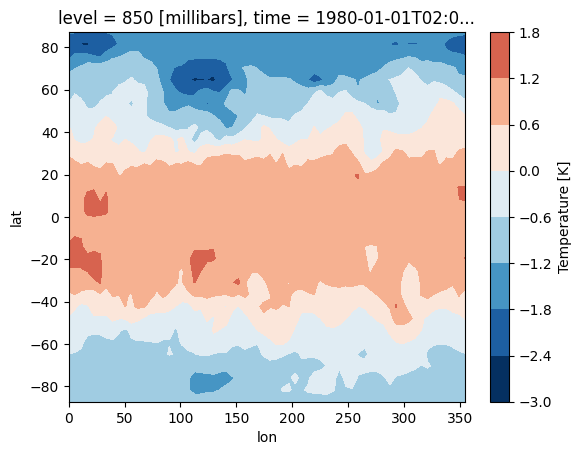

In [46]:
wb_train_ds._ds_norm['temperature'][2].sel(level=850).plot.contourf()

create a copy of the xarray data arrray to reuse the metadata for plotting

In [54]:
pred_da = xarray.DataArray(wb_train_ds._ds_norm['temperature'][2].sel(level=850))

In [48]:
pred_arr = ae_model.forward(wb_val_ds[2].to(device)).to('cpu').detach().numpy() 

In [50]:
pred_arr.shape

(1, 25, 32, 64)

In [52]:
pred_arr.values.shape

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [55]:
pred_da.values = pred_arr[0,0,:]

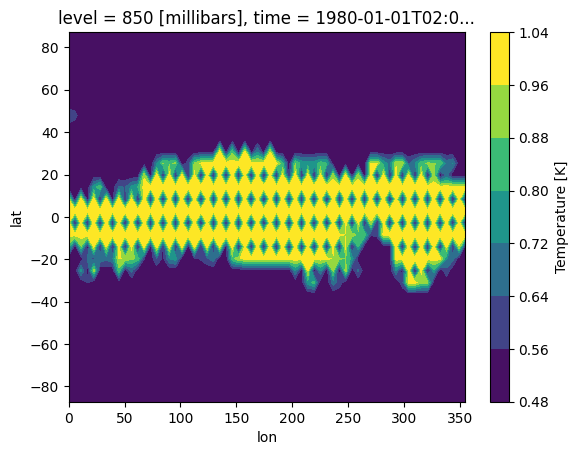

In [56]:
pred_da.plot.contourf()

### Evaluate the results
Now we want to compare our samples to the predictor. We will start looking at RMSE, using the scores package for evaluation.

In [ ]:
import scores

In [ ]:
scores.continuous.rmse(
    ae_model.forward(wb_val_ds[:10].to(device)).to('cpu').detach().numpy(), 
    wb_val_ds[:10].numpy()
)

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding
